In this script we analyse the proteome of 19 arabidopsis thaliana varieties. We use the proteomic search results obtained using variety specific, new assemblies, with all isoforms search results

In [20]:
# =========================================================
# Arabidopsis Founders Proteomics Analysis
# Project structure and directories
# =========================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# ---------------------------------------------------------
# Base project directories
# ---------------------------------------------------------

BASE_DIR = Path("/home/ggiordano/snap/main")

SCRIPT_DIR = BASE_DIR / "scripts" / "at_founders"

IMPORT_BASE   = BASE_DIR / "import" / "at_founders"
IMPORT_REPORT = IMPORT_BASE / "report"
IMPORT_MATRIX = IMPORT_BASE / "matrix"
IMPORT_STATS  = IMPORT_BASE / "stats"

EXPORT_DIR = BASE_DIR / "export" / "at_founders"
FIG_DIR    = EXPORT_DIR / "QC_plots"

DATA_DIR   = BASE_DIR / "data" / "at_founders"

# ---------------------------------------------------------
# Create directories
# ---------------------------------------------------------

for d in [EXPORT_DIR, FIG_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Validate import directories
# ---------------------------------------------------------

required_import_dirs = [IMPORT_REPORT, IMPORT_MATRIX, IMPORT_STATS]

for d in required_import_dirs:
    if d.exists():
        print(f"OK: Found {d}")
    else:
        print(f"WARNING: Missing directory -> {d}")

print("\nProject initialised")
print("Import:", IMPORT_BASE)
print("Export:", EXPORT_DIR)

OK: Found /home/ggiordano/snap/main/import/at_founders/report
OK: Found /home/ggiordano/snap/main/import/at_founders/matrix
OK: Found /home/ggiordano/snap/main/import/at_founders/stats

Project initialised
Import: /home/ggiordano/snap/main/import/at_founders
Export: /home/ggiordano/snap/main/export/at_founders


In [21]:
# =========================================================
# Load DIA-NN report files (.tsv)
# =========================================================

report_files = sorted(IMPORT_REPORT.glob("*_report.tsv"))

dfs = []

for f in report_files:

    accession = f.name.split("_")[0]

    df = pd.read_csv(f, sep="\t")
    df["Accession"] = accession

    dfs.append(df)

report_df = pd.concat(dfs, ignore_index=True)

print("Total rows:", report_df.shape[0])
print("Accessions loaded:", report_df["Accession"].nunique())

/tmp/ipykernel_3170368/4010985693.py:13: DtypeWarning: Columns (0: Protein.Names, 1: Genes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep="\t")
/tmp/ipykernel_3170368/4010985693.py:13: DtypeWarning: Columns (0: Protein.Names, 1: Genes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep="\t")
/tmp/ipykernel_3170368/4010985693.py:13: DtypeWarning: Columns (0: Protein.Names, 1: Genes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep="\t")
/tmp/ipykernel_3170368/4010985693.py:13: DtypeWarning: Columns (0: Protein.Names, 1: Genes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep="\t")
/tmp/ipykernel_3170368/4010985693.py:13: DtypeWarning: Columns (0: Protein.Names, 1: Genes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep="\t")
/tmp/ipyke

Total rows: 8689577
Accessions loaded: 19


Rows after precursor FDR: 8578477
Final summary shape: (76, 5)
Summary saved: /home/ggiordano/snap/main/data/at_founders/identification_summary_per_run.tsv


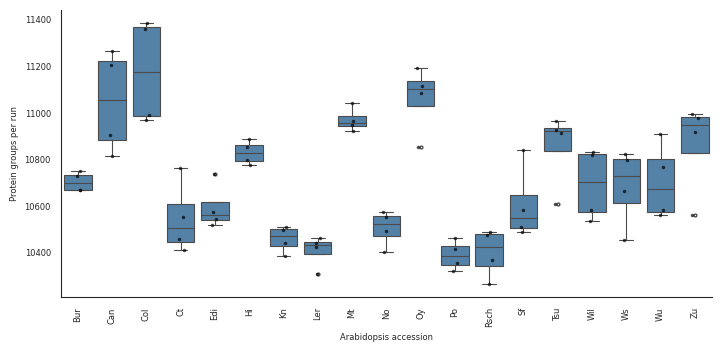

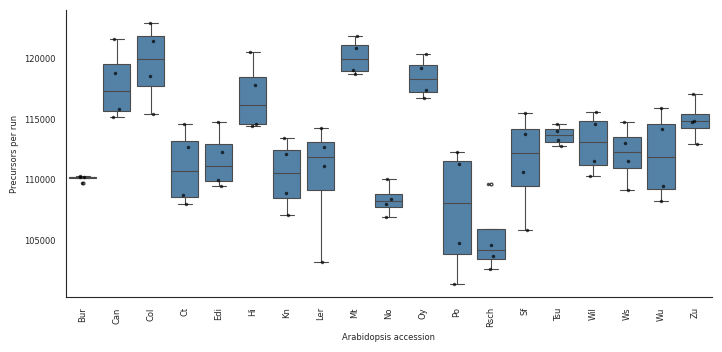

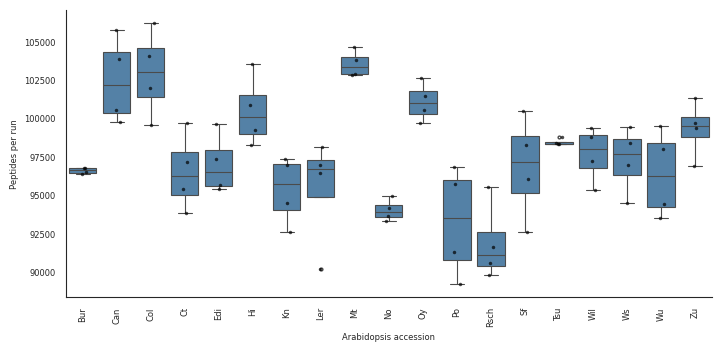


Figures saved in: /home/ggiordano/snap/main/export/at_founders/QC_plots


In [22]:
# =========================================================
# FDR filtering (precursor-level ONLY — correct for DIA-NN)
# =========================================================

filtered_df = report_df[
    (report_df["Q.Value"] <= 0.01) &
    (report_df["Global.Q.Value"] <= 0.01)
].copy()

print("Rows after precursor FDR:", filtered_df.shape[0])

# =========================================================
# Summary table
# =========================================================

summary = (
    filtered_df
    .groupby(["Accession","Run"])
    .agg(
        Proteins=("Protein.Group","nunique"),
        Precursors=("Precursor.Id","nunique"),
        Peptides=("Stripped.Sequence","nunique")
    )
    .reset_index()
)

# ensure integer type
summary["Proteins"] = summary["Proteins"].astype(int)
summary["Peptides"] = summary["Peptides"].astype(int)
summary["Precursors"] = summary["Precursors"].astype(int)

# remove duplicates (safety)
summary = summary.drop_duplicates()

print("Final summary shape:", summary.shape)

# =========================================================
# Save summary table (important)
# =========================================================

summary_file = DATA_DIR / "identification_summary_per_run.tsv"
summary.to_csv(summary_file, sep="\t", index=False)

print("Summary saved:", summary_file)

# =========================================================
# Plot settings (UNCHANGED aesthetics)
# =========================================================

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 6

sns.set_style("white")

FIG_SIZE = (7.2, 3.5)
COLOR = "steelblue"

# =========================================================
# Helper function for consistent plotting
# =========================================================

def plot_metric(df, y_col, ylabel, filename):

    df = df.copy()
    df = df.dropna(subset=[y_col, "Accession"])  # safety

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    sns.boxplot(
        data=df,
        x="Accession",
        y=y_col,
        color=COLOR,
        linewidth=0.8,
        fliersize=2,
        ax=ax
    )

    sns.stripplot(
        data=df,
        x="Accession",
        y=y_col,
        color="black",
        size=2.5,
        jitter=True,
        alpha=0.7,
        ax=ax
    )

    ax.set_xlabel("Arabidopsis accession")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=90)

    sns.despine()
    plt.tight_layout()

    fig.savefig(FIG_DIR / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{filename}.jpeg", dpi=300, bbox_inches="tight")

    plt.show()

# =========================================================
# Generate plots
# =========================================================

plot_metric(summary, "Proteins", "Protein groups per run", "proteins_per_run")
plot_metric(summary, "Precursors", "Precursors per run", "precursors_per_run")
plot_metric(summary, "Peptides", "Peptides per run", "peptides_per_run")

print("\nFigures saved in:", FIG_DIR)

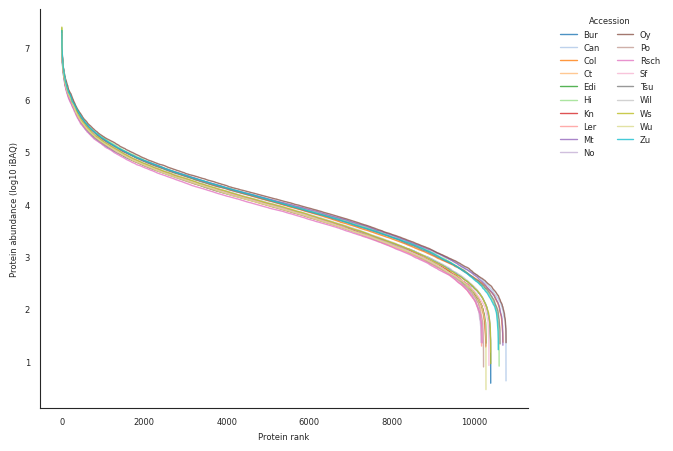

In [23]:
# =========================================================
# Rank–abundance curves per accession (improved)
# =========================================================

import numpy as np

matrix_files = sorted(IMPORT_MATRIX.glob("*_pg.csv"))

# slightly wider figure
fig, ax = plt.subplots(figsize=(8.5, 4.5))

# consistent color palette
accessions = sorted([f.name.split("_")[0] for f in matrix_files])
palette = sns.color_palette("tab20", n_colors=len(accessions))

for i, f in enumerate(matrix_files):

    accession = f.name.split("_")[0]

    pg = pd.read_csv(f, low_memory=False)

    # iBAQ columns
    ibaq_cols = [c for c in pg.columns if c.startswith("iBAQ")]

    # mean log2 iBAQ across replicates
    mean_log2 = pg[ibaq_cols].mean(axis=1, skipna=True)

    # convert log2 → log10
    mean_log10 = mean_log2 / np.log2(10)

    values = mean_log10.dropna().values

    # sort for rank-abundance
    values = np.sort(values)[::-1]

    ranks = np.arange(1, len(values) + 1)

    ax.plot(
        ranks,
        values,
        linewidth=1,
        alpha=0.8,
        color=palette[i],
        label=accession
    )

# ---------------------------------------------------------
# Styling
# ---------------------------------------------------------

ax.set_xlabel("Protein rank")
ax.set_ylabel("Protein abundance (log10 iBAQ)")

sns.despine()

# ---------------------------------------------------------
# Legend (2 columns, outside)
# ---------------------------------------------------------

ax.legend(
    title="Accession",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    ncol=2
)

# give more space to plot
plt.tight_layout(rect=[0, 0, 0.8, 1])

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

plt.savefig(FIG_DIR / "rank_abundance_per_accession.pdf", dpi=300)
plt.savefig(FIG_DIR / "rank_abundance_per_accession.jpeg", dpi=300)

plt.show()

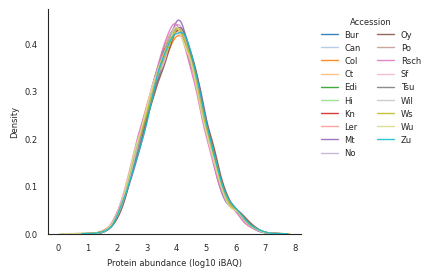

In [24]:
mm_to_inch = 1 / 25.4
fig_width = 140 * mm_to_inch   # wider than before
fig_height = 70 * mm_to_inch

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

accessions = sorted([f.name.split("_")[0] for f in matrix_files])
palette = sns.color_palette("tab20", n_colors=len(accessions))

for i, f in enumerate(matrix_files):

    accession = f.name.split("_")[0]

    pg = pd.read_csv(f, low_memory=False)

    ibaq_cols = [c for c in pg.columns if c.startswith("iBAQ")]

    mean_log2 = pg[ibaq_cols].mean(axis=1, skipna=True)
    mean_log10 = mean_log2 / np.log2(10)

    values = mean_log10.dropna()

    sns.kdeplot(
        values,
        ax=ax,
        linewidth=1,
        alpha=0.9,
        color=palette[i],
        label=accession
    )

# ---------------------------------------------------------
# Styling
# ---------------------------------------------------------

ax.set_xlabel("Protein abundance (log10 iBAQ)")
ax.set_ylabel("Density")

sns.despine()

# ---------------------------------------------------------
# Legend (2 columns + outside)
# ---------------------------------------------------------

ax.legend(
    title="Accession",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    ncol=2   # 🔥 key change
)

# give more space to plot area
plt.tight_layout(rect=[0, 0, 0.8, 1])

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

plt.savefig(FIG_DIR / "intensity_distribution_per_accession.pdf", dpi=300)
plt.savefig(FIG_DIR / "intensity_distribution_per_accession.jpeg", dpi=300)

plt.show()